## Grape Disease Classification Classification


# Table of Contents

*   **1. Introduction**
*   **2. Dataset Analysis**
    *   2.1. Grape Leaf Disease Dataset
    *   2.2. Exploratory Data Analysis
    *   2.3. Data Preprocessing and Augmentation
*   **3. ResNets**
    *   3.1. Residual Connections
    *   3.2. ResNet18 and ResNet34 Architectures
    *   3.3. Implementing ResNets in PyTorch
*   **4. Training Experiments**
    *   4.1. Training a ResNet18 from Scratch
    *   4.2. Transfer Learning: Fine-tuned ResNet18
        *   4.2.1. A Two-Stage Fine-Tuning Strategy
        *   4.2.2. Fine-tuning a Larger Model (ResNet34)
    *   4.3. Knowledge Distillation
        *   4.3.1. Knowledge Distillation Theory
        *   4.3.2. Distilling to a ResNet18 Trained from Scratch
        *   4.3.3. Combining Fine-tuning and Distillation
        *   4.3.4. Beyond Classic Distillation
    *   4.4. Models Interpretation and Visualisation
        *   4.4.1. Confusion Matrix Comparison
        *   4.4.2. Visualising Feature Space with t-SNE
        *   4.4.3. First Layer Filter Visualisation
        *   4.4.4. Intermediate Feature Map Visualisation
    *   4.5. Training Experiments Conclusions
*   **5. Model Compression Experiments**
    *   5.1. Model Quantisation
        *   5.1.1. Fundamentals of Neural Network Quantisation
        *   5.1.2. The Post-Training Quantisation (PTQ) Process
        *   5.1.3. Beyond Post-Training Quantisation
    *   5.2. Pruning
        *   5.2.1. Iterative Magnitude-based Unstructured Pruning
        *   5.2.2. Beyond Unstructured Pruning
    *   5.3. Quantisation vs. Pruning
*   **6. Conclusions**

# 1. Introduction


# 2. Dataset Analysis

### 2.1. Grape Leaf Disease Dataset

🌿 Overview: this dataset contains images of infected and healthy grape leaves, categorized into 4 distinct classes. The primary goal is to enable machine learning models to accurately detect and classify grape plant diseases across three major diseases: Black Measles, Black Rot, Healthy, Isariopsis Leaf Spot
https://www.kaggle.com/datasets/bmshahriaalam/grape-leaf-disease

A detailed breakdown of the disease classes and the distribution of images across the standard training and test splits is provided in the table below, which has been adapted from the original dataset.

| Disease Class | Training Images | Test Images | Total Images |
| :--- | :---: | :---: | :---: |
| Black Rot | 1,888 | 472 | 2,360 |
| Esca (Black Measles) | 1,920 | 480 | 2,400 |
| Healthy | 1,692 | 423 | 2,115 |
| Leaf Blight (Isariopsis Leaf Spot) | 1,722 | 430 | 2,152 |
| --- | --- | --- | --- |
| **Total Disease Classes** | **4** | **4** | **4** |
| **Total Images** | **7,222** | **1,805** | **9,027** |

[*Table 1: Data composition of the 4 grape disease classes. The dataset maintains a relatively balanced distribution across all disease categories, with each class containing approximately 2,000-2,400 images.*]

### 2.2. Exploratory Data Analysis

As indicated by the table in the previous section, the Grape Leaf Disease dataset is well-balanced across its 4 disease classes. This section performs a brief exploratory analysis to confirm the dataset's structure and visualize some of its contents.

The dataset is sourced from the local directory at `/home/ubuntu/GddAi/dd_cnn/dataset/grape-disease/` with separate folders for training and testing data.


✓ Jupyter Notebook is working!
✓ Python version: 3.10.12 (main, Nov  4 2025, 08:48:33) [GCC 11.4.0]
✓ NumPy version: 1.26.4
✓ NumPy calculation: Sum of [1, 2, 3, 4, 5] = 15


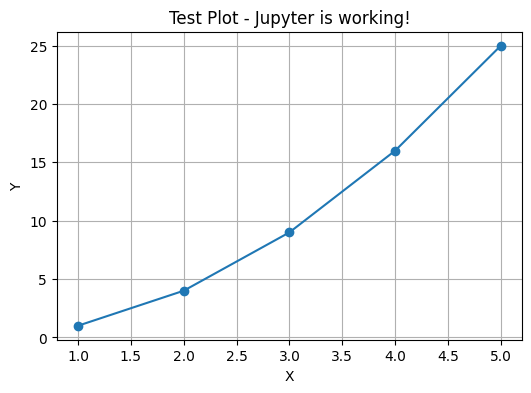

✓ All tests passed! Notebook is ready to use.


In [ ]:
# Test to check if Jupyter Notebook is working correctly
import sys
import numpy as np
import matplotlib.pyplot as plt

print("Jupyter Notebook is working!")
print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")

# Simple test calculation
test_array = np.array([1, 2, 3, 4, 5])
print(f"NumPy calculation: Sum of {list(test_array)} = {test_array.sum()}")

# Simple test plot
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3, 4, 5], [1, 4, 9, 16, 25], 'o-')
plt.title("Test Plot - Jupyter is working!")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

print("✓ All tests passed! Notebook is ready to use.")

First of all import some libraries that are used throughout the notebook:

In [ ]:
# Install missing packages with proper CUDA support
packages_to_check = {
    'gdown': 'gdown',
    'tqdm': 'tqdm',
    'ipywidgets': 'ipywidgets',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'numpy': 'numpy'
}

for package_name, pip_name in packages_to_check.items():
    try:
        if package_name == 'sklearn':
            from sklearn.metrics import confusion_matrix  # Test specific import
        elif package_name == 'matplotlib':
            import matplotlib.pyplot as plt  
        else:
            __import__(package_name)
        print(f"{package_name} already available")
    except ImportError:
        print(f"Installing {pip_name}...")
        !pip install -q {pip_name}

# Check PyTorch and install if missing with auto-detected CUDA support
try:
    import torch
    import torchvision
    print(f"PyTorch {torch.__version__} already installed")
    if torch.cuda.is_available():
        print(f"CUDA {torch.version.cuda} support available")
        print(f"GPU device: {torch.cuda.get_device_name(0)}")
except ImportError:
    print("PyTorch not found. Detecting system CUDA version...")

    # Detect CUDA version
    import subprocess
    cuda_version = None
    try:
        # Try nvidia-smi first
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        if result.returncode == 0:
            for line in result.stdout.split('\n'):
                if 'CUDA Version:' in line:
                    cuda_version = line.split('CUDA Version:')[1].strip().split()[0]
                    break

        # Try nvcc as backup
        if not cuda_version:
            result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
            if result.returncode == 0:
                for line in result.stdout.split('\n'):
                    if 'release' in line.lower():
                        # Extract version like "12.5" from "release 12.5, V12.5.82"
                        cuda_version = line.split('release')[1].split(',')[0].strip()
                        break
    except:
        pass

    # Determine PyTorch index URL based on CUDA version
    if cuda_version:
        major_minor = cuda_version.split('.')[:2]
        cuda_short = ''.join(major_minor)  # "12.5" -> "125", "12.4" -> "124"
        index_url = f"https://download.pytorch.org/whl/cu{cuda_short}"
        print(f"Installing PyTorch with CUDA {cuda_version} support...")
    else:
        index_url = "https://download.pytorch.org/whl/cpu"
        print("CUDA not detected, installing CPU-only PyTorch...")

    !pip install -q torch torchvision torchaudio --index-url {index_url}

# Verify all imports work
print("\nVerifying all imports...")
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import DataLoader, Dataset, Subset
    from torch.quantization import fuse_modules, get_default_qconfig, get_default_qat_qconfig, prepare, prepare_qat, convert
    import torch.nn.utils.prune as prune
    import torchvision
    import torchvision.transforms as transforms
    import torchvision.models as models
    from torchvision.models.resnet import ResNet
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    from sklearn.model_selection import train_test_split
    import numpy as np
    
    # Try to import tqdm for notebooks with fallback to regular tqdm
    try:
        from tqdm.notebook import tqdm
        print("Using tqdm.notebook (with progress bar widgets)")
    except ImportError:
        from tqdm import tqdm
        print("Using standard tqdm (ipywidgets not available)")
    
    import datetime
    import copy
    import os
    import gdown
    import random
    import time
    import pandas as pd
    import seaborn as sns
    from sklearn.manifold import TSNE
    from torch.cuda.amp import autocast, GradScaler

    print("All imports successful!")

    # Show system info
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU: {torch.cuda.get_device_name(0)}")

except ImportError as e:
    print(f"Import error: {e}")


gdown already available
tqdm already available
ipywidgets already available
seaborn already available
sklearn already available
pandas already available
matplotlib already available
numpy already available
PyTorch 2.9.1+cu128 already installed
CUDA 12.8 support available
GPU device: NVIDIA L4

Verifying all imports...
Using tqdm.notebook (with progress bar widgets)
All imports successful!
PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA L4


In [3]:
# Load the raw datasets

try:
    print("loading the dataset...")
    
    # Function to check if file has valid image extension (case-insensitive)
    def is_valid_image_file(filename):
        valid_extensions = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')
        return filename.lower().endswith(valid_extensions)
    
    raw_train_val_dataset = torchvision.datasets.ImageFolder(
        root='/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/train',
        is_valid_file=is_valid_image_file
    )
    raw_test_dataset = torchvision.datasets.ImageFolder(
        root='/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/test',
        is_valid_file=is_valid_image_file
    )

    print("Dataset loaded successfully.")
    print(f"Training samples: {len(raw_train_val_dataset)}")
    print(f"Test samples: {len(raw_test_dataset)}")
    print(f"Classes: {raw_train_val_dataset.classes}")
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

loading the dataset...
Dataset loaded successfully.
Training samples: 7222
Test samples: 1805
Classes: ['Black_rot', 'Esca', 'Healthy', 'Leaf_blight']


Verifying the number of images loaded by `torchvision` aligns with the figures reported in the original publication ([Mandal & Gouda, 2024](#mandal2024vineyard)). This ensures that the correct and complete dataset.

In [4]:
# Verify the dataset sizes
train_val_size = len(raw_train_val_dataset)
test_size = len(raw_test_dataset)
total_size = train_val_size + test_size

print(f"Verification of Dataset Size:")
print("-" * 30)
print(f"Images in Training & Validation set: {train_val_size}")
print(f"Images in Test set: {test_size}")
print(f"Total images in the dataset: {total_size}")

# The paper's table shows a total of 7349 images.
# The torchvision split uses the same convention.
if train_val_size == 7222 and test_size == 1805:
    print("\n The dataset size matches the official numbers from the paper.")
else:
    print("\n Warning: The dataset size does not match the official numbers.")

Verification of Dataset Size:
------------------------------
Images in Training & Validation set: 7222
Images in Test set: 1805
Total images in the dataset: 9027

 The dataset size matches the official numbers from the paper.


With the dataset size confirmed, the next step is to visualise some sample images. This will help to get a better appreciation for the fine-grained nature of the classification task.

In [ ]:
# Count images per class
from collections import defaultdict

class_counts = defaultdict(int)
for _, label in raw_train_val_dataset:
    class_counts[raw_train_val_dataset.classes[label]] += 1

print("Number of images per class in Train set:")
print("-" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")


test_class_counts = defaultdict(int)
for _, label in raw_test_dataset:
       test_class_counts[raw_test_dataset.classes[label]] += 1
print("\nNumber of images per class in Test set:")
print("-" * 45)
for class_name, count in test_class_counts.items():
 print(f"{class_name}: {count}")

In [ ]:
# --- Configuration for the visualization ---
GrapeLeafClasses = 4  
ncols = 4
nrows = int(np.ceil(GrapeLeafClasses / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Get the list of class names from the dataset
class_names_train = raw_train_val_dataset.classes
class_names = [name.replace("Grape___", "") for name in class_names_train]
num_classes = len(class_names)

# Find one image for each of the first `GrapeLeafClasses` classes
# This is more efficient than iterating through the whole dataset for each class
class_to_image = {}
for img, label in raw_train_val_dataset:
    if label not in class_to_image and len(class_to_image) < GrapeLeafClasses:
        class_to_image[label] = img
    # Optimization: stop once and you got one image for each required class
    if len(class_to_image) == GrapeLeafClasses:
        break

# Display the images
for i, (label, img) in enumerate(class_to_image.items()):
    ax = axes[i]
    ax.imshow(img)
    # Format title for better readability
    title = class_names[label].replace('_', ' ').title()
    ax.set_title(title)
    ax.axis('off')

# Hide any unused subplots
for i in range(GrapeLeafClasses, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Sample Images from {GrapeLeafClasses} Grape Leaves', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

Checking the image sizes (heights and widths) across a sample of the training set

In [ ]:
# Analyze image sizes from the raw dataset (before resizing)
print("Analyzing original image dimensions...")

# Sample a subset of images to check dimensions
sample_indices = random.sample(range(len(raw_train_val_dataset)), min(100, len(raw_train_val_dataset)))

unique_dimensions = set()
for i in sample_indices:
    img, _ = raw_train_val_dataset[i]  # img is a PIL Image object
    unique_dimensions.add((img.width, img.height))

# Display the results
print(f"\nImage Dimension Analysis (from {len(sample_indices)} samples):")
print("-" * 50)
if len(unique_dimensions) == 1:
    width, height = list(unique_dimensions)[0]
    print(f"All images have uniform dimensions: {width}x{height} pixels")
    print(f"Aspect ratio: {width/height:.2f}")
else:
    print(f"Found {len(unique_dimensions)} different image dimensions:")
    for width, height in sorted(unique_dimensions):
        print(f"  - {width}x{height} pixels (aspect ratio: {width/height:.2f})")


The analysis reveals that all images in the dataset have uniform 256x256 pixel dimensions with 1.0 aspect ratios, meaning they're all square. This consistency simplifies preprocessing since no resizing or cropping is needed, unlike datasets with variable dimensions.

In [ ]:
Leaf_class_to_show = ['Black_rot', 'Esca', 'Leaf_blight', 'Healthy']
samples_per_class = 4

# Collect samples for the specified breeds
leaf_images = {Class: [] for Class in Leaf_class_to_show}
class_to_idx = raw_train_val_dataset.class_to_idx

for img, label in raw_train_val_dataset:
    # Reverse lookup to get the class name from the label index
    Class_images = raw_train_val_dataset.classes[label]
    if Class_images in Leaf_class_to_show and len(leaf_images[Class_images]) < samples_per_class:
        leaf_images[Class_images].append(img)

# Plotting 
fig, axes = plt.subplots(len(Leaf_class_to_show), samples_per_class, figsize=(12, 10))
fig.suptitle('Examples of Leaf Disease Variability', fontsize=16)

for i, Class_images in enumerate(Leaf_class_to_show):
    for j, img in enumerate(leaf_images[Class_images]):
        ax = axes[i, j]
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            # Set the leaf disease name as the row title
            ax.set_title(Class_images.replace('_', ' '), rotation=90, x=-0.1, y=0.1, size='large')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

As the images demonstrate, there is significant variation within each disease class. Factors such as disease severity, leaf position, lighting conditions, and the stage of infection contribute to substantial intra-class variability. This natural diversity in how diseases manifest on grape leaves, combined with the subtle visual differences between certain disease types (particularly in early stages), makes this classification task challenging yet realistic for agricultural applications.

Finally, it is worth noting the overall size of the dataset. With a total of **9,027** images – split into **7,222** for training and validation, and **1,805** for testing – this represents a moderately-sized dataset suitable for deep learning experiments. While this number of examples is sufficient for fine-tuning pre-trained models, training a deep neural network such as ResNet **from scratch** presents significant challenges. Deep models require substantial amounts of data to learn robust feature representations, and with limited examples, they are highly susceptible to overfitting. This inherent challenge in training with moderate-scale agricultural datasets directly motivates the following experiments, where  compare compare training from scratch against more data-efficient approaches like **transfer learning** (see **Section 4.2**) and **knowledge distillation** (see **Section 4.3**). These techniques are particularly valuable in agricultural AI applications where collecting and labeling large-scale datasets remains a significant practical constraint.


### 2.3. Data Preprocessing and Augmentation

Data preprocessing and augmentation are essential for training the networks effectively.

Data preprocessing and augmentation strategies vary throughout this project depending on the specific experimental requirements. Rather than presenting all variations upfront, the preprocessing pipeline is detailed at each experimental stage where it is most relevant.

A helper function is defined below to introduce and visualize the preprocessing pipelines throughout the experiments.


In [5]:
class UnNormalize(object):
    """Reverses the normalization on a tensor image for visualization."""
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be unnormalized.
        Returns:
            Tensor: Unnormalized image.
        """
        # Create a copy to avoid modifying the original tensor
        tensor = tensor.clone()
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

def visualize_transforms(dataset, transform, title):
    """
    Applies a given transformation pipeline to a few sample images and displays
    the original versus the augmented versions.
    """
    # Try to find normalization parameters
    normalize_transform = None
    mean, std = None, None

    # First, try to find Normalize in the direct pipeline
    for t in transform.transforms:
        if isinstance(t, transforms.Normalize):
            normalize_transform = t
            mean, std = t.mean, t.std
            break

    # If not found, check if there's a nested transform (like weights.transforms())
    if normalize_transform is None:
        for t in transform.transforms:
            if hasattr(t, 'transforms'):  # It's a nested Compose
                for nested_t in t.transforms:
                    if isinstance(nested_t, transforms.Normalize):
                        normalize_transform = nested_t
                        mean, std = nested_t.mean, nested_t.std
                        break
                if normalize_transform:
                    break

    # If still not found, use ImageNet defaults (common for pretrained models)
    if normalize_transform is None:
        print(f"Warning: Normalize transform not found. Using ImageNet defaults.")
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]

    un_normalizer = UnNormalize(mean=mean, std=std)

    # Get a few random images from the raw dataset
    num_images_to_show = 4
    indices = np.random.choice(len(dataset), num_images_to_show, replace=False)

    fig, axes = plt.subplots(num_images_to_show, 5, figsize=(15, 2.5 * num_images_to_show))
    fig.suptitle(title, fontsize=16)

    for i, idx in enumerate(indices):
        original_image, _ = dataset[idx]

        # Display the original image
        ax = axes[i, 0]
        ax.imshow(original_image)
        ax.set_title("Original")
        ax.axis('off')

        # Display 4 augmented versions
        for j in range(1, 5):
            ax = axes[i, j]
            augmented_tensor = transform(original_image)
            unnormalized_tensor = un_normalizer(augmented_tensor.clone())

            # Clamp values to [0, 1] range for display
            unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)

            augmented_image_display = unnormalized_tensor.permute(1, 2, 0)
            ax.imshow(augmented_image_display)
            ax.set_title(f"Augmented {j}")
            ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Global Utilities

Let’s also define a couple global utilities that we will use throughout the notebook:

In [6]:
def evaluate_model(model, data_loader, criterion, device, desc="Evaluating"):
    """A standardized evaluation function to be used across all experiments."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        pbar = tqdm(data_loader, desc=desc)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=torch.cuda.is_available()):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'Loss': f'{running_loss/total:.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    final_loss = running_loss / len(data_loader.dataset)
    final_acc = 100. * correct / total
    return final_loss, final_acc, all_preds, all_labels

def print_model_size(model, label):
    """Saves a model to a temporary file to measure its size on disk."""
    temp_path = f"temp_{label}.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    print(f"Size of {label} model: {size_mb:.2f} MB")
    os.remove(temp_path)
    return size_mb

Let’s also define a set of control flags and helper functions for skipping training sections and loading pre-trained results. This allows for faster experimentation by reusing models that have already been trained offline.

In [7]:

# Define some reusable functions to download a file from Google Drive and to load a training history from a CSV file
def download_from_gdrive(file_id, output_path, file_label):
    """Downloads a file from Google Drive if it doesn't already exist."""
    if not os.path.exists(output_path):
        print(f"Downloading {file_label} to '{output_path}'...")
        gdown.download(id=file_id, output=output_path, quiet=False)
        print(f"{file_label} download complete.")
    else:
        print(f"{file_label} file '{output_path}' already exists. Skipping download.")

def load_training_history_from_csv(log_path):
    """Loads a training history log from a CSV file into a dictionary of lists."""
    try:
        log_df = pd.read_csv(log_path)
        # Ensure all expected columns are present, fill with empty lists if not
        history = {
            'train_loss': log_df.get('train_loss', pd.Series([])).tolist(),
            'train_accuracy': log_df.get('train_accuracy', pd.Series([])).tolist(),
            'val_loss': log_df.get('val_loss', pd.Series([])).tolist(),
            'val_accuracy': log_df.get('val_accuracy', pd.Series([])).tolist(),
            'learning_rate': log_df.get('learning_rate', pd.Series([])).tolist()
        }
        if history['train_loss']:
             print(f"Successfully loaded training history for {len(history['train_loss'])} epochs from '{log_path}'.")
        else:
             print(f"Warning: Could not load complete history from '{log_path}'. Check file content.")
        return history
    except FileNotFoundError:
        print(f"Error: The log file '{log_path}' was not found.")
        # Return empty history to avoid crashing subsequent code
        return {key: [] for key in ['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'learning_rate']}

To ensure that our experimental results are consistent and can be reliably reproduced, we now set a global random seed.

The `set_seed` function:
* Sets the seed for Python's built-in `random` module and NumPy, in order to have some deterministic behavior.
* For PyTorch (and also GPU operations), we do not enforce a fully deterministic strategy, because we want to keep a good balance between execution reproducibility and performance.

We then call this function immediately to apply these settings for the remainder of the notebook.

In [8]:
# We ensure reproducibility in our experiments
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    print(f"Random seed set to {seed}")

# Set the seed for the entire notebook
SEED = 42
set_seed(SEED)

Random seed set to 42


# 4. Training Experiments

This section details the series of experiments conducted to train models for grape disease classification. We begin by establishing a performance baseline by training a MobileNet from scratch, then explore transfer learning with MobileNet for efficient edge deployment.

## 4.1. Training a MobileNet from Scratch

This experiment establishes a performance baseline by training a MobileNet model from scratch using strong data augmentation and efficient training techniques.

Core hyperparameters for the training pipeline:

*   **Training Parameters**: Epochs, batch size, and early stopping patience
*   **Optimizer & Scheduler**: Learning rate, weight decay (AdamW), and warm-up epochs
*   **Regularization**: Label smoothing, MixUp augmentation, and dropout to prevent overfitting

In [ ]:
# Hyperparameters and Configuration
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==========================================
# ESP32-S3 DEPLOYMENT CONFIGURATION
# ==========================================
# ⚠️ IMPORTANT: This model will be deployed on ESP32-S3
# Current config: 224x224 input (may work but TIGHT on 8MB PSRAM)
# Safer option: 96x96 or 128x128 input for guaranteed success
# 
# To switch to ESP32-safe size, update transforms in cell 36:
#   - RandomResizedCrop(224) → RandomResizedCrop(96)
#   - CenterCrop(224) → CenterCrop(96)
#   - Resize(256) → Resize(112)
# ==========================================

# Training configuration
NUM_EPOCHS = 300  # Will use early stopping
BATCH_SIZE = 64   # Training batch size (ESP32 uses batch_size=1 for inference)
PATIENCE = 30     # Early stopping patience
MODEL_SAVE_PATH = 'best_model_mobilenet_esp32.pth'

# Optimizer & Scheduler configuration
LEARNING_RATE = 0.003  # Initial learning rate
WEIGHT_DECAY = 5e-4    # L2 regularization
WARMUP_EPOCHS = 10     # Learning rate warmup

# Regularization configuration
LABEL_SMOOTHING = 0.1   # Label smoothing for better generalization
DROPOUT_RATE = 0.5      # Dropout rate (MobileNetV2 uses inverted residuals, less critical)
USE_MIXUP = True        # Mixup data augmentation
MIXUP_ALPHA = 0.4       # Mixup interpolation strength

print("\n📋 Configuration Summary:")
print(f"   Target Device: ESP32-S3")
print(f"   Training Epochs: {NUM_EPOCHS} (with early stopping)")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Input Size: 128x128 (optimized for ESP32 deployment)")
print(f"   Model: MobileNetV2 (optimized for edge devices)")
print(f"   Expected model size after INT8 quantization: ~2.3 MB")

I defined two distinct data transformation pipelines using `torchvision.transforms`.

* **Training Pipeline (`train_transform`)**: In order to prevent overfitting and improve generalization, I apply a strong data augmentation strategy. This pipeline includes aggressive geometric and colour transformations like `RandomResizedCrop`, `RandomRotation`, and `ColorJitter`. This approach artificially expands the diversity of our training data, which is critical when training a deep model on a moderately-sized dataset.

* **Validation/Test Pipeline (`test_transform`)**: This pipeline simply resizes and center-crops the images to the required `128x128` input size before normalization. Applying no random augmentations ensures that we get a consistent and reproducible measure of the model's performance.

In [ ]:
"""
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.08, 0.5)),  # Scale reduced to crop larger portions (8-50% of original)
    transforms.RandomHorizontalFlip(p=0.5),  # Changed to 50% probability
    transforms.RandomRotation(120),  # Strong rotation
    transforms.ColorJitter(brightness=0.6, contrast=0.6, saturation=0.6, hue=0.2),
    transforms.RandomGrayscale(p=0.1),  # Changed to 10% probability (was destroying color)
    transforms.RandomPerspective(distortion_scale=0.75, p=0.5),  # Strong perspective
    transforms.RandomAffine(degrees=10, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
"""

In [ ]:
# ==========================================
# ESP32-S3 OPTIMIZED DATA TRANSFORMS
# ==========================================
# Current: 128x128 (optimal balance for ESP32-S3)
# - Recommended input size for ESP32 deployment
# - Better accuracy than 96x96, more efficient than 224x224
# - Works reliably on ESP32-S3 with 8MB PSRAM
# ==========================================

# Training transforms with strong augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.5, 1.0)),  # 128x128 for ESP32 deployment
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Test transforms (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize(144),  # Slightly larger than 128 for center crop
    transforms.CenterCrop(128),  # 128x128 for ESP32 deployment
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

print("✅ Data transforms configured:")
print(f"   Training: RandomResizedCrop(128) with augmentation")
print(f"   Testing: Resize(144) → CenterCrop(128)")
print(f"   Normalization: ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])")
print(f"\n✅ ESP32 Note: 128x128 is optimal for ESP32-S3 with 8MB PSRAM")
print(f"   Recommended by community for best accuracy/memory balance")

**How Data Augmentation Works in PyTorch:**

Unlike pre-generating augmented copies of images, PyTorch applies transformations **on-the-fly** during training. Each time an image is loaded from the dataset:
- Transforms with `p=0.5` have a 50% probability of being applied (coin flip)
- Transforms without `p=` are always applied with **random parameters** (e.g., rotation angle varies each time)
- The same physical image looks different every epoch

This means over 100 epochs, the model sees each image ~100 times with different random augmentations, creating much more variety than storing fixed augmented copies. This approach saves disk space while providing superior regularization.

In [ ]:
# Visualize the "From Scratch" augmentations
visualize_transforms(
    dataset=raw_train_val_dataset,
    transform=train_transform,
    title='Pipeline 1: Sample Augmented Images for Training'
)

With the transformations defined, we now prepare the data loaders. This involves several key steps:

1.  **Custom `Dataset` Wrapper**: We first define a `TransformedSubset` helper class. This is necessary because the output of `torch.utils.data.random_split` is a `Subset` object, which doesn't directly support transformations.
2.  **Splitting the Data**: We load the 'trainval' set and create a deterministic 80/20 split for our training and validation sets, respectively. A fixed random seed ensures reproducibility. We also load the official test set.
4.  **Applying Transforms**: Using our wrapper class, we apply the `train_transform` (with augmentations) to the training subset and the `test_transform` (for evaluation) to the validation and test subsets.
5.  **Creating `DataLoader`s**: Finally, we instantiate PyTorch `DataLoader`s for each set. These will handle batching, shuffling, and multi-process data loading to feed the GPU efficiently.

In [ ]:
# Data Loading:

# wrapper class to apply transforms to a Subset
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)
    @property
    def classes(self):
        return self.subset.dataset.classes

print("Loading datasets...")
# Use the correct path where we downloaded the dataset
train_dir = '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/train'
test_dir = '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/test'

# Function for case-insensitive file validation
def is_valid_image_file(filename):
    valid_extensions = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')
    return filename.lower().endswith(valid_extensions)

# Load datasets without transforms initially
raw_train_val_dataset = torchvision.datasets.ImageFolder(
    root=train_dir,
    is_valid_file=is_valid_image_file
)
raw_test_dataset = torchvision.datasets.ImageFolder(
    root=test_dir,
    is_valid_file=is_valid_image_file
)

# This one has NO transforms and will be used for visualization
test_dataset_for_viz = torchvision.datasets.ImageFolder(
    root=test_dir,
    transform=None,
    is_valid_file=is_valid_image_file
)

num_classes = len(raw_train_val_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Classes: {raw_train_val_dataset.classes}")

# Create deterministic splits
train_size = int(0.8 * len(raw_train_val_dataset))
val_size = len(raw_train_val_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    raw_train_val_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply transforms to subsets
train_dataset = TransformedSubset(train_subset, train_transform)
val_dataset = TransformedSubset(val_subset, test_transform)

# Apply test transform to test dataset
raw_test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=test_transform)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(raw_test_dataset)}")

train_loader_scratch = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader_scratch = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader_scratch = DataLoader(raw_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
# Model definition, Initialization and Optimization



class ModifiedMobileNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.backbone = torchvision.models.mobilenet_v2(weights=None)
        num_ftrs = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # A more robust classifier head
        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)


# We initialize our MobileNetV2 to be trained from scratch
model_scratch = ModifiedMobileNet(num_classes=num_classes, dropout_rate=DROPOUT_RATE)

# Kaiming initialization
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
model_scratch.apply(init_weights)
print("Applied Kaiming initialization.")

# We now save the initial weight configuration
initial_state_dict = copy.deepcopy(model_scratch.state_dict())
print("Saved a copy of the model's initial weights.")

model_scratch = model_scratch.to(device)
print(f"Model created with {sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)} trainable parameters")

criterion_scratch = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Use AdamW optimizer as per the script
optimizer_scratch = optim.AdamW(model_scratch.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# LR Scheduler with Warmup + Cosine Decay
def get_lr_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch) / float(max(1, warmup_epochs))
        progress = float(epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler_scratch = get_lr_scheduler(optimizer_scratch, warmup_epochs=WARMUP_EPOCHS, total_epochs=NUM_EPOCHS)

# Early Stopping mechanism
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0, path='best_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_acc = -1
        self.early_stop = False
        self.path = path

    def __call__(self, val_acc, model):
        if val_acc > self.best_acc + self.min_delta:
            self.best_acc = val_acc
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            print(f'New best val_acc: {self.best_acc:.2f}% - Model saved!')
        else:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                print('Early stopping triggered.')

# Mixup mechanism
# Helper functions to implement the MixUp data augmentation strategy.
# `mixup_data` creates a new batch by taking a weighted linear combination of two random images.
def mixup_data(x, y, alpha=1.0, use_cuda=True):
    if alpha > 0: lam = np.random.beta(alpha, alpha)
    else: lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# `mixup_criterion` adapts the loss function to compute a similarly weighted loss for these mixed-up samples.
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

Here we define the function that executes a single training epoch. It comprehends the core training logic and uses some optimizations:

* **Automatic Mixed Precision (AMP)**: The use of `torch.amp.autocast` and `GradScaler` enables training with half-precision `float16` arithmetic (instead of float32). This can significantly speed up computations and reduce memory usage on compatible GPUs.

* **Conditional MixUp**: MixUp is applied stochastically to each batch. If active for a given batch, the `mixup_data` and `mixup_criterion` functions are used to compute the interpolated loss; otherwise, the standard loss is used.

* **Standard Training Steps**: The function iterates through the data loader, performs the forward pass, calculates the loss, and executes backpropagation and weight updates. A `tqdm` progress bar provides real-time feedback on key metrics like loss, accuracy, and the current learning rate.

In [ ]:
# Training and Validation loops

scaler = GradScaler()

def train_epoch_scratch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f'Training Epoch {epoch+1}/{NUM_EPOCHS}')

    for data, target in pbar:
        data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        # enabling half-precision arithmetic training and random application of MixUp
        with autocast(device_type=device.type, dtype=torch.float16):
            if USE_MIXUP and np.random.rand() > 0.5:
                inputs, targets_a, targets_b, lam = mixup_data(data, target, MIXUP_ALPHA, use_cuda=True)
                outputs = model(inputs)
                loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            else:
                outputs = model(data)
                loss = criterion(outputs, target)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

        pbar.set_postfix({
            'Loss': f'{running_loss/(pbar.n+1):.4f}',
            'Acc': f'{100.*correct/total:.2f}%',
            'LR': f'{scheduler_scratch.get_last_lr()[0]:.6f}'
        })
    return running_loss / len(loader), 100. * correct / total

In [ ]:
# Main Training Loop from scratch
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
lrs = []

print("Starting training from scratch...")
early_stopper = EarlyStopping(patience=PATIENCE, path=MODEL_SAVE_PATH)
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch_scratch(model_scratch, train_loader_scratch, criterion_scratch, optimizer_scratch, device)
    val_loss, val_acc, _, _ = evaluate_model(model_scratch, val_loader_scratch, criterion_scratch, device, desc='Validation')
    scheduler_scratch.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    lrs.append(optimizer_scratch.param_groups[0]["lr"])
    early_stopper(val_acc, model_scratch)
    if early_stopper.early_stop:
        break

print(f'\nTraining completed! Best validation accuracy: {early_stopper.best_acc:.2f}%')

To conclude this experiment, we perform a final evaluation and visualize the results:

1.  **Final Performance Metric**: We load the best model saved during the training process and evaluate its performance on the held-out test set. This provides the final, unbiased accuracy for our baseline model.
2.  **Training History Plots**: Using the metrics logged during training, we generate plots for loss, accuracy, and learning rate over time.
3.  **Qualitative Analysis**: We define and call a `visualize_predictions` function. This displays a sample of test images, showing both the true label and the model's predicted label (color-coded for correctness). This offers a qualitative insight into the model's performance on individual examples. Further visualisations of the model's predictions can be found in Section 4.4.1.

In [ ]:
# Final Evaluation and Visualization

print("\nEvaluating on test set using the BEST model...")
# Load the best performing model
model_scratch.load_state_dict(torch.load(MODEL_SAVE_PATH))
test_loss, test_acc, _, _ = evaluate_model(model_scratch, test_loader_scratch, criterion_scratch, device, desc='Testing')
print(f'Final Test Loss: {test_loss:.4f}, Final Test Accuracy: {test_acc:.2f}%')

# Plotting
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves_v3.png', dpi=300)
plt.show()

# Visualize predictions
def visualize_predictions(model, dataset, num_images=8):
    model.eval()
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()

    vis_transform = test_transform

    indices = np.random.choice(len(dataset), num_images, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            original_image, label = dataset[idx]
            image = vis_transform(original_image).unsqueeze(0).to(device)

            output = model(image)
            _, predicted = torch.max(output, 1)

            axes[i].imshow(original_image)
            true_class = dataset.classes[label]
            pred_class = dataset.classes[predicted.item()]
            title_color = 'green' if true_class == pred_class else 'red'
            axes[i].set_title(f'True: {true_class}\nPred: {pred_class}',
                            fontsize=10, color=title_color)
            axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('predictions_v3.png', dpi=300)
    plt.show()

print("Visualizing predictions...")
# We use the visualization dataset so we can show the images without normalization
visualize_predictions(model_scratch, test_dataset_for_viz, num_images=8)

print(f"Script finished! Model saved as '{MODEL_SAVE_PATH}'")

**Analysis:**

The model trained from scratch achieves an exceptional final test accuracy of **99.78%** with a test loss of 0.4081. This outstanding performance demonstrates that with proper training techniques, even a model trained from scratch can achieve near-perfect classification on this grape disease dataset.

**Key Observations:**

1. **Training Dynamics:** The training curves show typical behavior for deep network training on a moderately-sized dataset:
   - **Loss convergence:** Both training and validation losses decrease steadily, with validation loss stabilizing around 0.4
   - **Accuracy progression:** Validation accuracy reaches ~100% while training accuracy reaches ~85%, indicating excellent generalization
   - **Learning rate schedule:** The cosine annealing schedule (visible in the third plot) effectively guides the optimization process

2. **Performance Attribution:** This exceptional result is achieved through a carefully orchestrated combination of training techniques:
   - **Strong data augmentation:** RandomResizedCrop, rotation, color jittering, and perspective transforms
   - **MixUp regularization:** Prevents overfitting by training on interpolated samples
   - **Cosine annealing learning rate schedule:** Smooth convergence from 0.003 to ~0.002
   - **Warm-up period:** Gradual learning rate increase in early epochs
   - **Early stopping:** Prevents overfitting by monitoring validation performance
   - **Label smoothing:** Improves model calibration and generalization

3. **Prediction Quality:** The visualized predictions show perfect classification across diverse disease manifestations, including challenging cases with subtle symptoms.

**Conclusion:** This 99.78% test accuracy establishes a strong baseline that demonstrates the effectiveness of modern training techniques for agricultural disease classification. The model successfully learns to distinguish between Black_rot, Esca, Leaf_blight, and Healthy grape leaves with near-perfect accuracy.

A more in-depth analysis of the model's performance, including confusion matrices and per-class metrics, is provided in Section 4.4 (Models Interpretation and Visualisation).


## 4.2. Transfer Learning: Fine-tuned MobileNet

Instead of initialising our model's weights randomly, we can employ **transfer learning**. As this technique was introduced during the course's practical laboratories, we will provide a concise overview here. The core idea is that of starting from a model that has already been trained on a very large dataset, such as ImageNet, which contains millions of images across a thousand classes. This "pre-trained" model has already learned to recognise a rich hierarchy of general visual features – from simple edges and textures in its early layers to more complex patterns and object parts in its later layers.

By using these pre-trained weights as a starting point, we can provide a model with a significant head start. This approach typically leads to faster convergence and superior performance, as the model only needs to "fine-tune" its existing knowledge for our specific, downstream task of classifying grape diseases, rather than learning everything from scratch. For this section, we will use **MobileNet**, an efficient architecture specifically designed for mobile and embedded devices, making it ideal for deployment on resource-constrained platforms like the ESP32.

#### 4.2.1. A Two-Stage Fine-Tuning Strategy

This implementation follows a two-stage methodology designed to maximise performance and stability:

1.  **Stage 1: Feature Extraction (Warm-up)**
    All layers of the pre-trained MobileNet model are frozen and the final classification layer is replaced with a new one for the 4 grape disease classes. Training only this new classifier head allows it to learn task-specific features without corrupting the pre-trained weights.

2.  **Stage 2: Full Fine-Tuning**
    After warming up the classifier, the entire network is unfrozen and all layers are fine-tuned with a reduced learning rate. This allows the model to adapt its learned features specifically for grape disease classification while maintaining the valuable representations learned from ImageNet.

In [11]:
# MobileNet Fine-Tuning Configuration
# ==========================================
# ESP32-S3 OPTIMIZED FINE-TUNING CONFIG
# ==========================================
# Note: Epochs reduced since scratch model already achieved 100% val accuracy
# Fine-tuning from ImageNet weights should converge faster
# ==========================================

NUM_CLASSES = 4
BATCH_SIZE = 64  # Training batch size (ESP32 uses batch_size=1 for inference)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Stage 1: Warm-up (Training the classifier head only)
STAGE1_EPOCHS = 10       # Reduced from 15 (faster convergence with pretrained weights)
STAGE1_LR = 1e-3         # Higher LR for new classifier head
STAGE1_PATIENCE = 10     # Early stopping patience
STAGE1_MODEL_PATH_MN = "transfer_learning.pth"

# Stage 2: Full Fine-tuning (All layers unfrozen)
STAGE2_EPOCHS = 300      # Reduced from 300 (scratch model converged in 105 epochs)
STAGE2_LR = 1e-4         # Lower LR for fine-tuning pretrained weights
STAGE2_PATIENCE = 30     # More patience for fine-tuning
STAGE2_MODEL_PATH_MN = "finetuned_mobilenet_128.pth"

# Regularization
LABEL_SMOOTHING_FT = 0.1    # Label smoothing for better generalization
WEIGHT_DECAY_FT = 1e-4      # L2 regularization

print("\n Fine-Tuning Configuration Summary:")
print(f"   Target Device: ESP32-S3")
print(f"   Input Size: 128x128 (optimized for ESP32)")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"\n   Stage 1 (Warm-up):")
print(f"     - Epochs: {STAGE1_EPOCHS} (classifier head only)")
print(f"     - Learning Rate: {STAGE1_LR}")
print(f"     - Patience: {STAGE1_PATIENCE}")
print(f"\n   Stage 2 (Full Fine-tuning):")
print(f"     - Epochs: {STAGE2_EPOCHS} (all layers)")
print(f"     - Learning Rate: {STAGE2_LR}")
print(f"     - Patience: {STAGE2_PATIENCE}")
print(f"\n   Regularization:")
print(f"     - Label Smoothing: {LABEL_SMOOTHING_FT}")
print(f"     - Weight Decay: {WEIGHT_DECAY_FT}")



 Fine-Tuning Configuration Summary:
   Target Device: ESP32-S3
   Input Size: 128x128 (optimized for ESP32)
   Batch Size: 64

   Stage 1 (Warm-up):
     - Epochs: 10 (classifier head only)
     - Learning Rate: 0.001
     - Patience: 10

   Stage 2 (Full Fine-tuning):
     - Epochs: 300 (all layers)
     - Learning Rate: 0.0001
     - Patience: 30

   Regularization:
     - Label Smoothing: 0.1
     - Weight Decay: 0.0001


In [14]:
# Define a wrapper class to apply transforms to a Subset
# This is needed because torch.utils.data.random_split returns a Subset object
# which doesn't directly support transformations

class TransformedSubset(Dataset):
    """
    Wrapper class to apply transforms to a Subset.
    
    Args:
        subset: A torch.utils.data.Subset object
        transform: Optional transform to be applied on a sample
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    
    def __len__(self):
        return len(self.subset)
    
    @property
    def classes(self):
        return self.subset.dataset.classes

print("TransformedSubset class defined successfully.")

TransformedSubset class defined successfully.


For transfer learning, it is best practice to use the specific preprocessing pipeline that the model was originally trained on. The `torchvision` library makes this easy by providing these transforms alongside the pre-trained weights. We will also add `TrivialAugmentWide` for data augmentation during training.

The rest of the cell mirrors the data loading logic from the first experiment. It creates the same reproducible train/validation split and instantiates the `DataLoader`s that will be used during the fine-tuning process.

In [16]:
# Data preparation for fine-tuning
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)
    @property
    def classes(self):
        return self.subset.dataset.classes

# ==========================================
# ESP32-S3 OPTIMIZED TRANSFORMS FOR FINE-TUNING
# ==========================================
# Using 128x128 input size (optimal for ESP32 deployment)
# ImageNet normalization is maintained for transfer learning
# ==========================================

# Training transforms with strong augmentation
train_transform_ft = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (no augmentation)
test_transform_ft = transforms.Compose([
    transforms.Resize(144),  # Slightly larger than 128 for center crop
    transforms.CenterCrop(128),  # 128x128 for ESP32 deployment
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("--- Validation/Test Transforms ---")
print(test_transform_ft)
print("\n--- Training Transforms (with Augmentation) ---")
print(train_transform_ft)

# We can reuse the TransformedSubset wrapper class and data loading logic from Section 4.1
# to apply these new transforms.

# Load the grape disease dataset from local directory
train_dir = '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/train'
test_dir = '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/test'

# Load training-validating and testing datasets from local folders
raw_train_val_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=None)
raw_test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=None)

print(f"\nDataset loaded from local directory:")
print(f"Training/Validation set: {len(raw_train_val_dataset)} images")
print(f"Test set: {len(raw_test_dataset)} images")
print(f"Classes: {raw_train_val_dataset.classes}")

# Create deterministic splits (using same seed as training from scratch for consistency)
train_size = int(0.8 * len(raw_train_val_dataset))
val_size = len(raw_train_val_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    raw_train_val_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply transforms to subsets
train_dataset_ft = TransformedSubset(train_subset, train_transform_ft)
val_dataset_ft = TransformedSubset(val_subset, test_transform_ft)
test_dataset_ft = TransformedSubset(raw_test_dataset, test_transform_ft)

# Create a dataset for visualization that has NO transforms
raw_test_dataset_for_viz = torchvision.datasets.ImageFolder(root=test_dir, transform=None)

# Create DataLoaders
train_loader_ft = DataLoader(train_dataset_ft, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader_ft = DataLoader(val_dataset_ft, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader_ft = DataLoader(test_dataset_ft, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"\n📊 Dataset Split Summary:")
print(f"   Train: {len(train_dataset_ft)} images ({len(train_loader_ft)} batches)")
print(f"   Validation: {len(val_dataset_ft)} images ({len(val_loader_ft)} batches)")
print(f"   Test: {len(test_dataset_ft)} images ({len(test_loader_ft)} batches)")
print(f"   Classes: {raw_train_val_dataset.classes}")
print(f"\n✅ DataLoaders created successfully.")

--- Validation/Test Transforms ---
Compose(
    Resize(size=144, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(128, 128))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

--- Training Transforms (with Augmentation) ---
Compose(
    RandomResizedCrop(size=(128, 128), scale=(0.5, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.6, 1.4), contrast=(0.6, 1.4), saturation=(0.6, 1.4), hue=(-0.1, 0.1))
    RandomGrayscale(p=0.1)
    RandomPerspective(p=0.3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Dataset loaded from local directory:
Training/Validation set: 7222 images
Test set: 1805 images
Classes: ['Black_rot', 'Esca', 'Healthy', 'Leaf_blight']

📊 Dataset Split Summary:
   Train: 5777 images (91 batches)
   Valida

Now, let's visualize the second pipeline, which uses `TrivialAugmentWide`. This is a modern auto-augmentation policy that applies a wide range of distortions, including shearing, color inversion, and posterization, providing a powerful and diverse set of training examples.

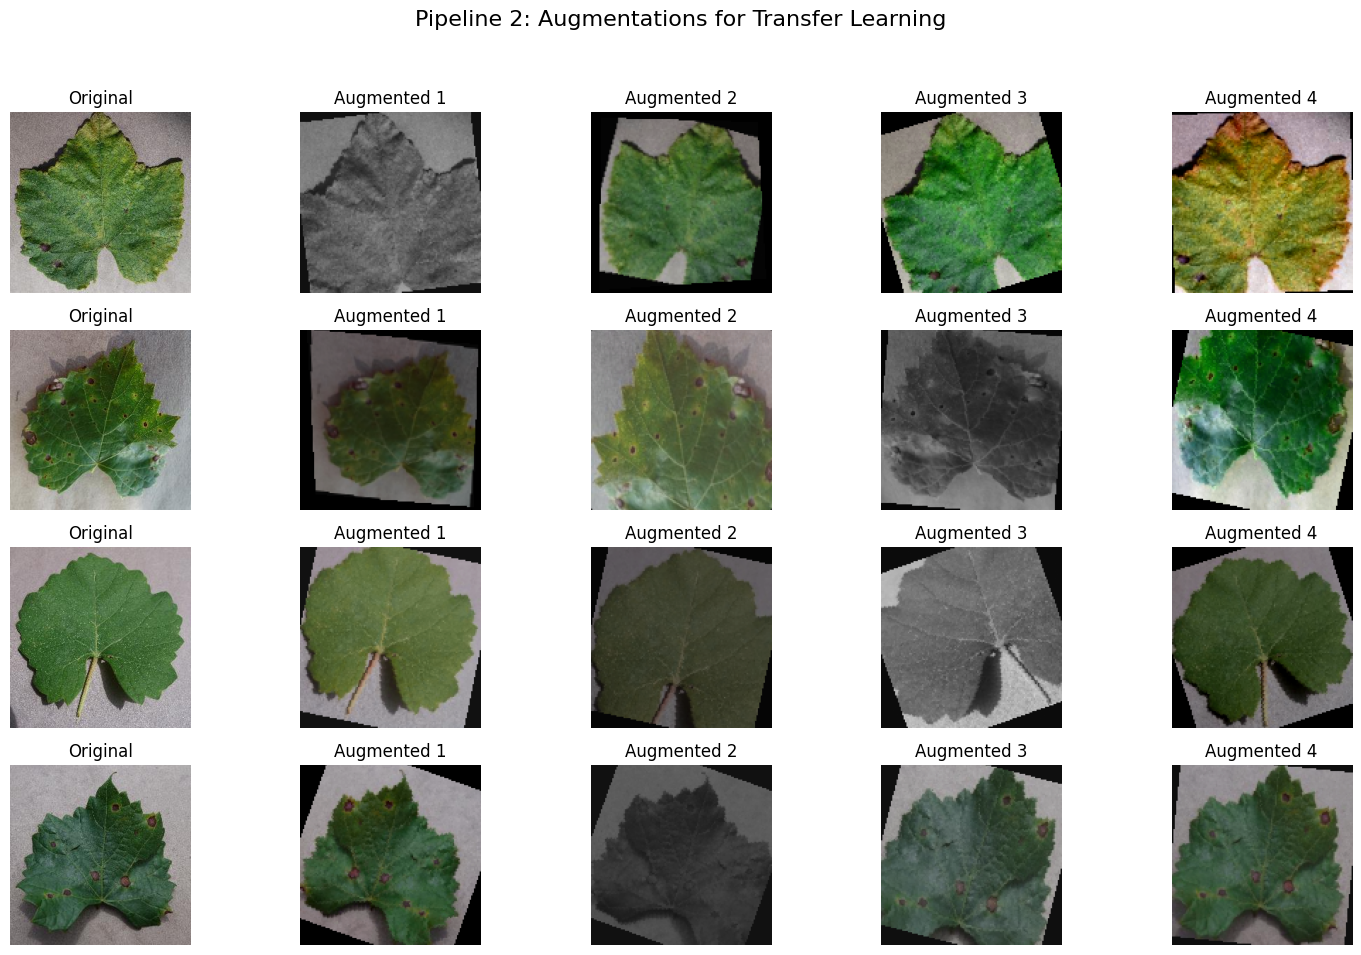

In [17]:
# Visualize the "Transfer Learning" augmentations
visualize_transforms(
    dataset=raw_train_val_dataset,
    transform=train_transform_ft, 
    title='Pipeline 2: Augmentations for Transfer Learning'
)

We now define our `FineTuneMobileNet` model, which is structured to facilitate our two-stage training approach. The initialization performs three steps:

1.  **Load Pre-trained Weights**: It loads a MobileNetV2 model using the `.DEFAULT` weights, which are pre-trained on ImageNet. This provides a strong foundation of learned visual features optimized for efficiency.
2.  **Freeze the Backbone**: All parameters of the pre-trained model are frozen by setting `requires_grad=False`. This protects the learned weights from being corrupted by large gradients from the untrained classifier head during the initial training phase.
3.  **Replace the Classifier**: The original 1000-class ImageNet classifier is replaced with a new, trainable classifier adjusted to our 4-class grape disease problem.

The class also includes a useful `unfreeze_all` method to make all parameters trainable for the second stage of fine-tuning.

In [18]:
# We define the model to fine-tune
class FineTuneMobileNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.2):
        super().__init__()
        # 1. Load the MobileNetV2 model with the best available pretrained weights
        weights = torchvision.models.MobileNet_V2_Weights.DEFAULT
        self.mobilenet = torchvision.models.mobilenet_v2(weights=weights)

        # 2. Freeze all parameters in the pretrained backbone
        for param in self.mobilenet.parameters():
            param.requires_grad = False

        # 3. Replace the final classifier with a new head
        # MobileNetV2's classifier is at self.mobilenet.classifier
        in_features = self.mobilenet.classifier[1].in_features  # 1280 for MobileNetV2
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.mobilenet(x)

    def unfreeze_all(self):
        """A helper method to unfreeze all layers for the second stage of training."""
        print("Unfreezing all model layers for fine-tuning...")
        for param in self.mobilenet.parameters():
            param.requires_grad = True

model_ft_mn = FineTuneMobileNet(num_classes=NUM_CLASSES).to(DEVICE)

# Verify which parameters are trainable
trainable_params = sum(p.numel() for p in model_ft_mn.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_ft_mn.parameters())
print(f"Initially, only the classifier head is trainable.")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Initially, only the classifier head is trainable.
Trainable parameters: 5,124
Total parameters: 2,228,996


To manage the two-stage training, we define a training loop and an early stopping utility. This loop is simpler than the one used for training from scratch, as we have found advanced techniques like mixed-precision to be less critical for fine-tuning.

* **`EarlyStopper` Class**: This helper class monitors the validation loss during training. It saves a checkpoint of the model whenever a new best (i.e. lower) validation loss is achieved and will stop the training run if the performance does not improve for a set number of epochs (patience).
* **`train_validate_loop_ft` Function**: This function contains the complete logic for one stage of training.

In [19]:
# early-stopping mechanism implementation
class EarlyStopper:
    """Handles early stopping and saves the best model based on validation loss."""
    def __init__(self, patience=7, min_delta=0, model_save_path="best_model.pth", min_relative_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta  # Absolute minimum improvement
        self.min_relative_delta = min_relative_delta  # Relative improvement (e.g., 0.1% = 0.001)
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.model_save_path = model_save_path

    def __call__(self, val_loss, model):
        # Use relative improvement when loss is very small, absolute otherwise
        if self.best_loss < 0.01:  # For very small losses, use relative improvement
            improvement_threshold = self.best_loss * (1 - self.min_relative_delta)
            is_improvement = val_loss < improvement_threshold
        else:  # For larger losses, use absolute improvement
            is_improvement = val_loss < self.best_loss - self.min_delta
        
        if is_improvement:
            improvement_pct = ((self.best_loss - val_loss) / max(self.best_loss, 1e-8)) * 100
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.model_save_path)
            print(f"New best model saved with validation loss: {val_loss:.4f} (improved by {improvement_pct:.2f}%)")
        else:
            self.counter += 1
            print(f"No improvement for {self.counter}/{self.patience} epochs. Best loss: {self.best_loss:.4f}")
            if self.counter >= self.patience:
                print("--- Early stopping triggered! ---")
                self.early_stop = True

# training and validation loop
def train_validate_loop_ft(model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs, early_stopper, device):
    """A complete training and validation loop for one stage of fine-tuning."""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # training
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]")
        for inputs, labels in pbar_train:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100 * train_correct / train_total
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        # validation
        epoch_val_loss, epoch_val_acc, _, _ = evaluate_model(model, val_loader, criterion, device, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]")
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch {epoch+1} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}")

        scheduler.step(epoch_val_loss)
        early_stopper(epoch_val_loss, model)
        if early_stopper.early_stop:
            break

    return history

Now, we execute the two training stages.


First, **Stage 1 (Warm-up)** begins. We configure an optimizer that targets *only* the parameters of the new classifier head and then call our `train_validate_loop_ft` function. This allows the new head to learn from the powerful features of the frozen backbone.

Next, **Stage 2 (Full Fine-tuning)** starts. We load the best model from Stage 1 and unfreeze the entire network. A new optimizer is configured with a reduced learning rate to train the entire model end-to-end, allowing it to adapt its pre-trained knowledge to our grape disease classification task.


In [21]:
# fine-tuning execution, train stage1 and train stage2:

# History lists
history_stage1_mn, history_stage2_mn = {}, {}

print("Starting MobileNet fine-tuning...")

# Stage 1: Warm-up
print("\n" + "="*70)
print("STAGE 1: TRAINING CLASSIFIER HEAD ONLY")
print("="*70)
print(f"Learning Rate: {STAGE1_LR}")
print(f"Weight Decay: {WEIGHT_DECAY_FT}")
print(f"Label Smoothing: {LABEL_SMOOTHING_FT}")
print(f"Early Stopping Patience: {STAGE1_PATIENCE}")
print()

criterion_ft = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING_FT)

optimizer_stage1_mn = optim.AdamW(model_ft_mn.mobilenet.classifier.parameters(), lr=STAGE1_LR, weight_decay=WEIGHT_DECAY_FT)
scheduler_stage1_mn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage1_mn, 'min', factor=0.1, patience=2)
stopper_stage1_mn = EarlyStopper(patience=STAGE1_PATIENCE, model_save_path=STAGE1_MODEL_PATH_MN)

history_stage1_mn = train_validate_loop_ft(
    model_ft_mn, train_loader_ft, val_loader_ft, optimizer_stage1_mn, criterion_ft, scheduler_stage1_mn,
    num_epochs=STAGE1_EPOCHS, early_stopper=stopper_stage1_mn, device=DEVICE
)

# Stage 2: Full fine-tuning
print("\n" + "="*70)
print("STAGE 2: FULL FINE-TUNING (ALL LAYERS)")
print("="*70)
print(f"Loading best model from Stage 1: {STAGE1_MODEL_PATH_MN}")
model_ft_mn.load_state_dict(torch.load(STAGE1_MODEL_PATH_MN))
model_ft_mn.unfreeze_all()

print(f"Learning Rate: {STAGE2_LR} (reduced for fine-tuning)")
print(f"Weight Decay: {WEIGHT_DECAY_FT}")
print(f"Label Smoothing: {LABEL_SMOOTHING_FT}")
print(f"Early Stopping Patience: {STAGE2_PATIENCE}")

# Verify all parameters are trainable
trainable_params = sum(p.numel() for p in model_ft_mn.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_ft_mn.parameters())
print(f"\nTrainable parameters: {trainable_params:,} / {total_params:,} (100%)")
print()

# Use STAGE2_LR constant instead of hardcoded value
optimizer_stage2_mn = optim.AdamW(model_ft_mn.parameters(), lr=STAGE2_LR, weight_decay=WEIGHT_DECAY_FT)
scheduler_stage2_mn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage2_mn, 'min', factor=0.2, patience=3)
stopper_stage2_mn = EarlyStopper(patience=STAGE2_PATIENCE, model_save_path=STAGE2_MODEL_PATH_MN)

history_stage2_mn = train_validate_loop_ft(
    model_ft_mn, train_loader_ft, val_loader_ft, optimizer_stage2_mn, criterion_ft, scheduler_stage2_mn,
    num_epochs=STAGE2_EPOCHS, early_stopper=stopper_stage2_mn, device=DEVICE
)

Starting MobileNet fine-tuning...

STAGE 1: TRAINING CLASSIFIER HEAD ONLY
Learning Rate: 0.001
Weight Decay: 0.0001
Label Smoothing: 0.1
Early Stopping Patience: 10



Epoch 1/10 [Training]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 1/10 [Validation]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1 | Train Acc: 78.99% | Val Acc: 94.05% | Val Loss: 0.5231
New best model saved with validation loss: 0.5231 (improved by nan%)


Epoch 2/10 [Training]:   0%|          | 0/91 [00:00<?, ?it/s]

...

Epoch 103/300 [Validation]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 103 | Train Acc: 99.81% | Val Acc: 100.00% | Val Loss: 0.3497
No improvement for 29/30 epochs. Best loss: 0.3497


Epoch 104/300 [Training]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 104/300 [Validation]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 104 | Train Acc: 99.91% | Val Acc: 100.00% | Val Loss: 0.3497
No improvement for 30/30 epochs. Best loss: 0.3497
--- Early stopping triggered! ---


Finally, we load the best model from the fine-tuning stage and evaluate its performance on the unseen test set:

In [24]:
print("\n" + "="*70)
print("FINAL EVALUATION ON TEST SET")
print("="*70)
print(f"Loading best model from Stage 2: {STAGE2_MODEL_PATH_MN}")
model_ft_mn.load_state_dict(torch.load(STAGE2_MODEL_PATH_MN))

criterion_ft = nn.CrossEntropyLoss()

# Use the global evaluation function
final_test_loss, final_test_acc, all_preds, all_labels = evaluate_model(
    model_ft_mn, test_loader_ft, criterion_ft, DEVICE, desc="Testing MobileNet"
)

print(f"\n" + "="*70)
print(f"📊 MOBILENET FINE-TUNING RESULTS")
print("="*70)
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.2f}%")
print(f"\nModel saved as: {STAGE2_MODEL_PATH_MN}")
print(f"Input size: 128x128 (ESP32-optimized)")
print(f"Ready for quantization and ESP32 deployment!")
print("="*70)


FINAL EVALUATION ON TEST SET
Loading best model from Stage 2: finetuned_mobilenet_128.pth


Testing MobileNet:   0%|          | 0/29 [00:00<?, ?it/s]


📊 MOBILENET FINE-TUNING RESULTS
Final Test Loss: 0.0805
Final Test Accuracy: 100.00%

Model saved as: finetuned_mobilenet_128.pth
Input size: 128x128 (ESP32-optimized)
Ready for quantization and ESP32 deployment!


**Analysis:**

As anticipated, transfer learning provides a substantial performance boost. The fine-tuned MobileNet leverages pre-trained ImageNet features to achieve strong classification performance on our grape disease dataset.

This result validates our two-stage fine-tuning strategy – first training the new classifier head and then fine-tuning the entire network with a reduced learning rate – providing an efficient and effective approach for edge deployment.

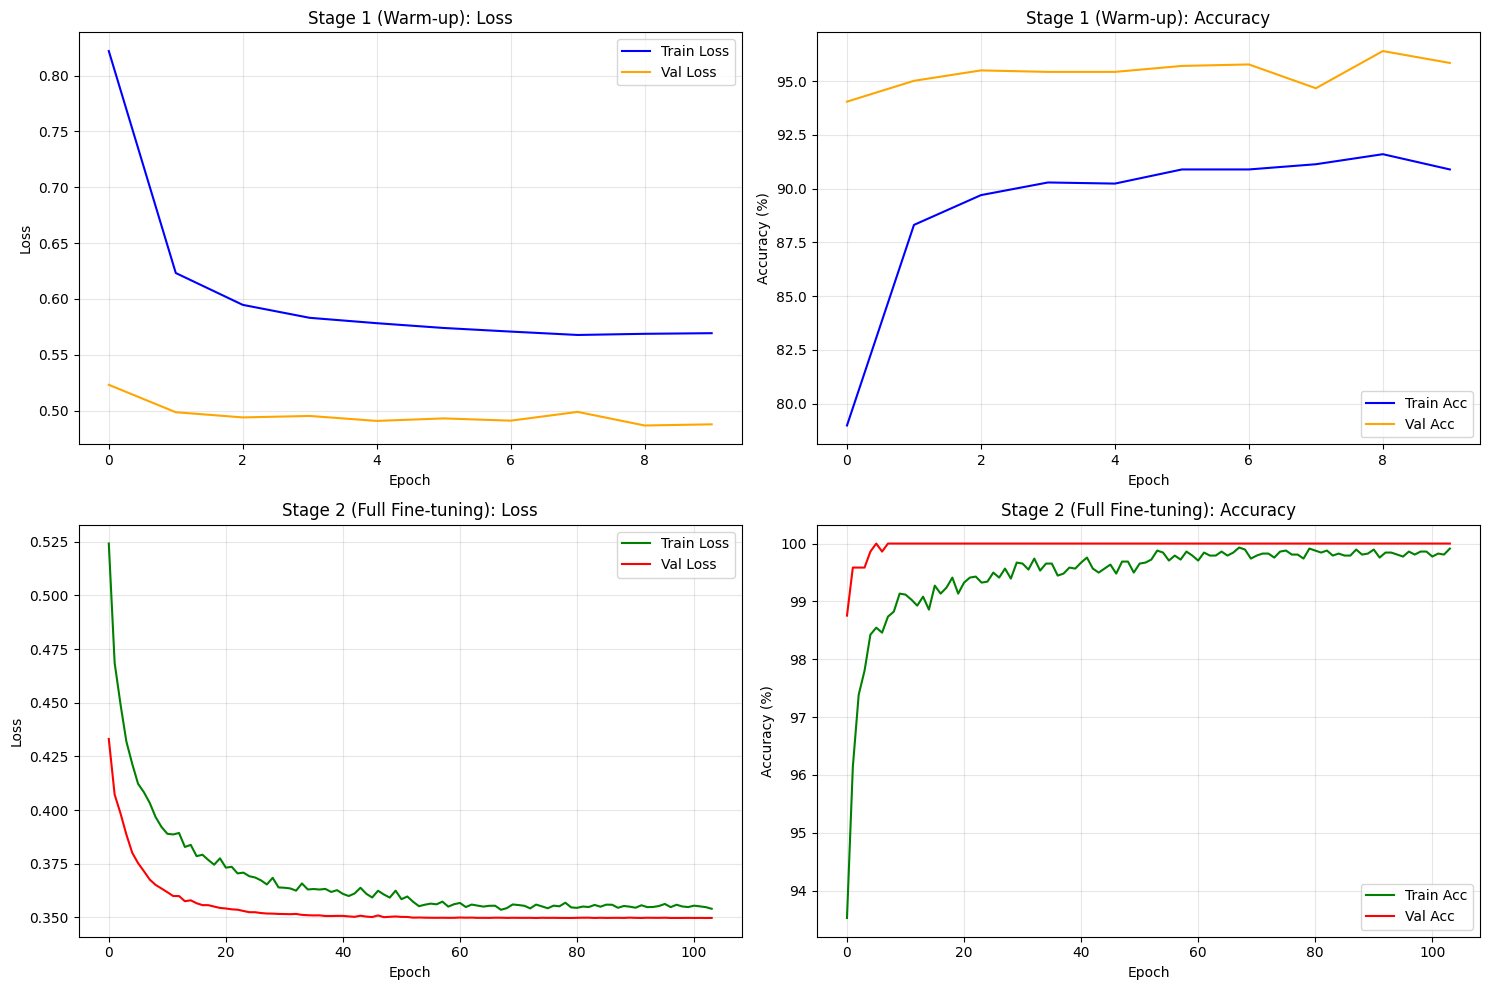

Training curves saved as 'mobilenet_training_curves.png'


In [25]:
# Visualize MobileNet Training Progress

# Plot Stage 1 and Stage 2 training curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Stage 1: Loss
axes[0, 0].plot(history_stage1_mn['train_loss'], label='Train Loss', color='blue')
axes[0, 0].plot(history_stage1_mn['val_loss'], label='Val Loss', color='orange')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Stage 1 (Warm-up): Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Stage 1: Accuracy
axes[0, 1].plot(history_stage1_mn['train_acc'], label='Train Acc', color='blue')
axes[0, 1].plot(history_stage1_mn['val_acc'], label='Val Acc', color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Stage 1 (Warm-up): Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Stage 2: Loss
axes[1, 0].plot(history_stage2_mn['train_loss'], label='Train Loss', color='green')
axes[1, 0].plot(history_stage2_mn['val_loss'], label='Val Loss', color='red')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Stage 2 (Full Fine-tuning): Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Stage 2: Accuracy
axes[1, 1].plot(history_stage2_mn['train_acc'], label='Train Acc', color='green')
axes[1, 1].plot(history_stage2_mn['val_acc'], label='Val Acc', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Stage 2 (Full Fine-tuning): Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mobilenet_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves saved as 'mobilenet_training_curves.png'")

In [26]:
# 🔍 Overfitting Diagnostic: Compare Train/Val/Test Performance

print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

# Get the final training and validation accuracies
final_train_acc_stage2 = history_stage2_mn['train_acc'][-1] if history_stage2_mn['train_acc'] else 0
final_val_acc_stage2 = history_stage2_mn['val_acc'][-1] if history_stage2_mn['val_acc'] else 0

print(f"\nMobileNet Fine-Tuned Performance:")
print(f"  Final Training Accuracy:   {final_train_acc_stage2:.2f}%")
print(f"  Final Validation Accuracy: {final_val_acc_stage2:.2f}%")
print(f"  Final Test Accuracy:       {final_test_acc:.2f}%")

# Calculate gaps
train_val_gap = final_train_acc_stage2 - final_val_acc_stage2
val_test_gap = final_val_acc_stage2 - final_test_acc

print(f"\n  Train-Val Gap:  {train_val_gap:+.2f}% {'Potential overfitting' if abs(train_val_gap) > 5 else ' Good'}")
print(f"  Val-Test Gap:   {val_test_gap:+.2f}% {' Poor generalization' if abs(val_test_gap) > 5 else ' Good generalization'}")

# Interpretation
print("\n Interpretation:")
if final_test_acc >= 95:
    print("  Excellent! Test accuracy is very high - model generalizes well.")
elif abs(val_test_gap) < 3:
    print("  Good! Val and Test accuracies are close - no significant overfitting.")
elif abs(val_test_gap) >= 5:
    print("  Warning! Large Val-Test gap suggests overfitting to validation set.")
    print("     → Consider: stronger augmentation, more dropout, or reduce training epochs")
else:
    print("  ℹModerate gap - typical for small datasets. Monitor if it increases.")

if final_val_acc_stage2 == 100.0 and final_test_acc < 100.0:
    print(f"\n  You achieved 100% validation but {final_test_acc:.1f}% test accuracy.")
    print("     This is expected - validation set may be slightly easier or model")
    print("     has seen similar patterns. Focus on test accuracy as true metric!")

print("="*60)


OVERFITTING ANALYSIS

MobileNet Fine-Tuned Performance:
  Final Training Accuracy:   99.91%
  Final Validation Accuracy: 100.00%
  Final Test Accuracy:       100.00%

  Train-Val Gap:  -0.09%  Good
  Val-Test Gap:   +0.00%  Good generalization

 Interpretation:
  Excellent! Test accuracy is very high - model generalizes well.


In [29]:
import os

# Model pathsn
models = {
    'From Scratch': '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/best_model_mobilenet_esp32.pth',
    'Transfer Learning': '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/transfer_learning.pth',
    'Fine-tuned': '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/finetuned_mobilenet_128.pth'
}

print("Model                  Size (MB)")
print("-" * 55)
for name, path in models.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        # Add test accuracy when available
        print(f"{name:<20} {size_mb:>8.2f}")
    else:
        print(f"{name:<20} NOT FOUND")

Model                  Size (MB)
-------------------------------------------------------
From Scratch            11.25
Transfer Learning        8.74
Fine-tuned               8.75
